# 组织资本

```{index} single: Organization Capital
```

## 概述

本讲座描述了由 {cite:t}`Prescott_Visscher_1980` 提出的**组织资本**理论。

普雷斯科特和维斯彻将组织资本定义为企业积累的关于其员工、团队和生产过程的信息。

这些信息是企业的一项*资产*，因为它影响生产可能性集，并且与产出共同生产。

调整组织资本存量的成本约束了企业的增长率，这为以下现象提供了解释：

1. 为什么企业增长率与企业规模无关（基布拉特定律）
1. 为什么快速增长的调整成本是内生产生的，而不是被假定的

该论文提供了组织资本的三个例子：

* *人员信息*：关于员工与任务之间匹配的知识
* *团队信息*：关于工人群体之间如何协作的知识
* *企业专用人力资本*：通过在职培训提升的员工技能

在每种情况下，投资可能性都会导致企业以共同的速率增长，从而在快速规模调整的成本递增的同时产生规模报酬不变。

```{note}
该理论与 {cite:t}`Coase_1937` 和 {cite:t}`Williamson_1975` 关于企业性质的观点有关。

普雷斯科特和维斯彻强调企业作为信息仓库的角色，并认为企业内部创造了激励机制以促进对该信息的有效积累和使用。
```

让我们从一些导入开始：

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 基本思想

企业是信息的仓库。

在企业内部，创造了激励机制以促进对该信息的有效积累和使用。

普雷斯科特和维斯彻利用这一概念来解释关于企业增长和规模分布的某些事实。

关键洞见是：信息积累的过程自然会导致

1. *规模报酬不变*，以及
2. *快速企业规模调整的成本递增*

规模报酬不变解释了为什么观察不到唯一的最优企业规模（参见 {cite:t}`Stigler_1958`）。

如果没有调整成本，企业在面对市场需求变化时的投资模式将呈现出我们观察不到的不连续性。

此外，如果没有对快速增长的成本惩罚，第一个发现先前未开发市场的企业将通过在有利可图的投资出现时占用所有这些投资来抢占竞争，从而意味着比实际更普遍的垄断。


## 人员信息作为组织资本

```{index} single: Organization Capital; Personnel Information
```

组织资本的第一个例子是关于员工与任务之间匹配的信息。

### 设置

工人拥有不同的技能和才能。

变量 $\theta$ 衡量一个工人对某种特定工作的适应能力。

* $\theta$ 高的工人在需要反复关注细节的任务中具有比较优势
* $\theta$ 低的工人在需要广泛定义职责的工作中具有比较优势

$\theta$ 的总体分布是均值为零、精度（方差的倒数）为 $\pi$ 的正态分布：

$$
\theta \sim N(0, 1/\pi)
$$

当从劳动力池中雇用一名工人时，工人和雇主都不知道 $\theta$。

两者都只知道总体分布。

### 三项任务

如果生产 $q$ 单位的产出，假设：

* $\varphi_1 q$ 名工人被分配到*任务 1*（筛选）
* $\varphi q$ 名工人被分配到*任务 2*
* 其余工人被分配到*任务 3*

其中 $\varphi_1 + 2\varphi = 1$。

```{note}
固定系数技术要求在职务 2 和 3 中的人员数量与分配到职务 1 的人员数量之间保持恒定比率。
```

对于任务 1（筛选任务），单位生产成本对于分配人员的 $\theta$ 值是*不变*的。

然而，工人的 $\theta$ 越大，他在任务 2 中的产出相对于任务 3 中的产出就越大。

因此：

* $\theta$ 高度为正的工人更适合任务 2
* $\theta$ 高度为负的工人更适合任务 3

### 贝叶斯学习

任务 2 或任务 3 中的表现无法在个人层面观察到。

但是，关于工人 $\theta$ 值的信息可以从观察其在任务 1（筛选任务）中的表现获得。

监督学徒的专家每期确定一个 $z$ 值：

$$
z_{it} = \theta_i + \epsilon_{it}
$$ (eq:signal)

其中 $\epsilon_{it} \sim N(0, 1)$ 在工人 $i$ 和期数 $t$ 上都是独立分布的。

在筛选工作中对一名工人进行 $n$ 次观察后，$\theta$ 的*后验分布*是正态分布，具有

*后验均值：*

$$
m = \frac{1}{\pi + n} \sum_{k=1}^{n} z_k
$$ (eq:post_mean)

*后验精度：*

$$
h = \pi + n
$$ (eq:post_prec)

因此，关于一个人的知识完全由这一对 $(m, h)$ 来刻画。

In [2]:
def bayesian_update(z_observations, prior_precision):
    """
    观察信号后计算后验均值和精度。
    """
    n = len(z_observations)
    h = prior_precision + n
    m = np.sum(z_observations) / h
    return m, h

让我们可视化当我们观察一名真实 $\theta = 0.8$ 的工人时后验如何演变：

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


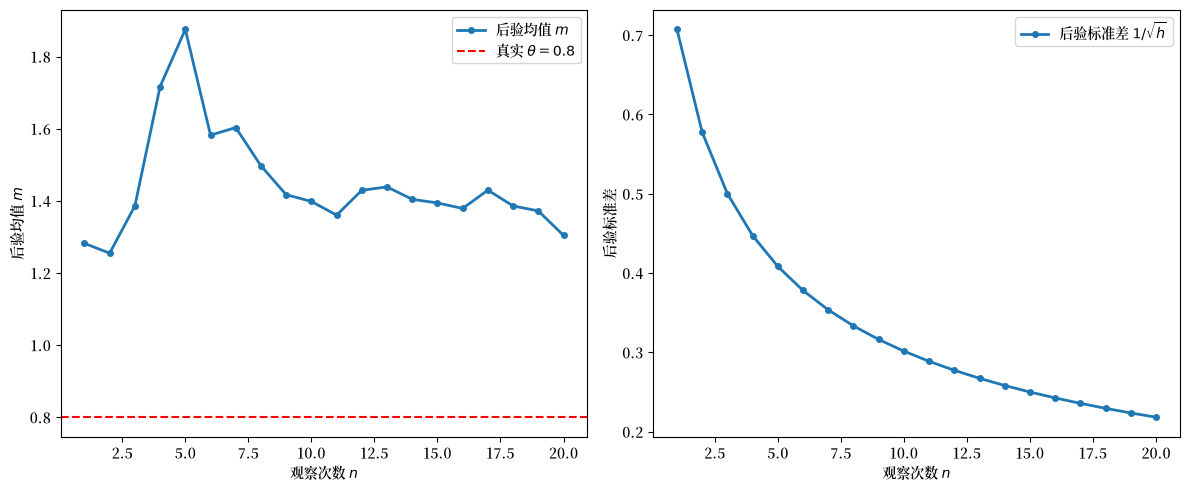

In [3]:
np.random.seed(0)

θ_true = 0.8
π = 1.0

T = 20
ε = np.random.randn(T)
z_signals = θ_true + ε

posterior_means = []
posterior_stds = []

for n in range(1, T + 1):
    m, h = bayesian_update(z_signals[:n], π)
    posterior_means.append(m)
    posterior_stds.append(1 / np.sqrt(h))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(range(1, T + 1), posterior_means, '-o', markersize=4, lw=2,
        label='后验均值 $m$')
ax.axhline(θ_true, color='r', linestyle='--',
           label=fr'真实 $\theta = {θ_true}$')
ax.set_xlabel('观察次数 $n$')
ax.set_ylabel('后验均值 $m$')
ax.legend()

ax = axes[1]
ax.plot(range(1, T + 1), posterior_stds, '-o', markersize=4, lw=2,
        label=r'后验标准差 $1/\sqrt{h}$')
ax.set_xlabel('观察次数 $n$')
ax.set_ylabel('后验标准差')
ax.legend()

plt.tight_layout()
plt.show()

随着筛选观察次数 $n$ 的增加，后验均值收敛到真实的 $\theta$，后验不确定性以 $1/\sqrt{n}$ 的速率缩小。

### 单位生产成本

在非顺序分配规则下，资历最深的员工被分配到职务 2 和 3，而较新的员工留在筛选任务中。

$m > 0$ 的工人被分配到任务 2，$m \leq 0$ 的工人被分配到任务 3。

假设在 $n$ 个筛选期后进行此分配，单位生产成本为：

$$
c(n) = c_1 + c_2 + c_3 - E\{\theta \mid m > 0\} + E\{\theta \mid m \leq 0\}
$$ (eq:unit_cost)

由于 $m$ 服从正态分布，对 {eq}`eq:unit_cost` 中的条件期望进行求值得到作为 $n$ 函数的单位成本：

$$
c(n) = c - 0.7978 \frac{n}{\pi(\pi + n)}
$$ (eq:cost_n)

其中 $c = c_1 + c_2 + c_3$ 且 $0.7978 = 2 \int_0^{\infty} \frac{t}{\sqrt{2\pi}} e^{-t^2/2} dt$。

```{note}
常数 $0.7978 \approx \sqrt{2/\pi}$ 是标准半正态分布的均值。

它来源于对正态分布计算 $E[\theta \mid m > 0] - E[\theta \mid m \leq 0]$。
```

函数 $c(n)$ 随 $n$ 以*递减的速率*下降。

更多的筛选观察降低了成本，但收益递减。

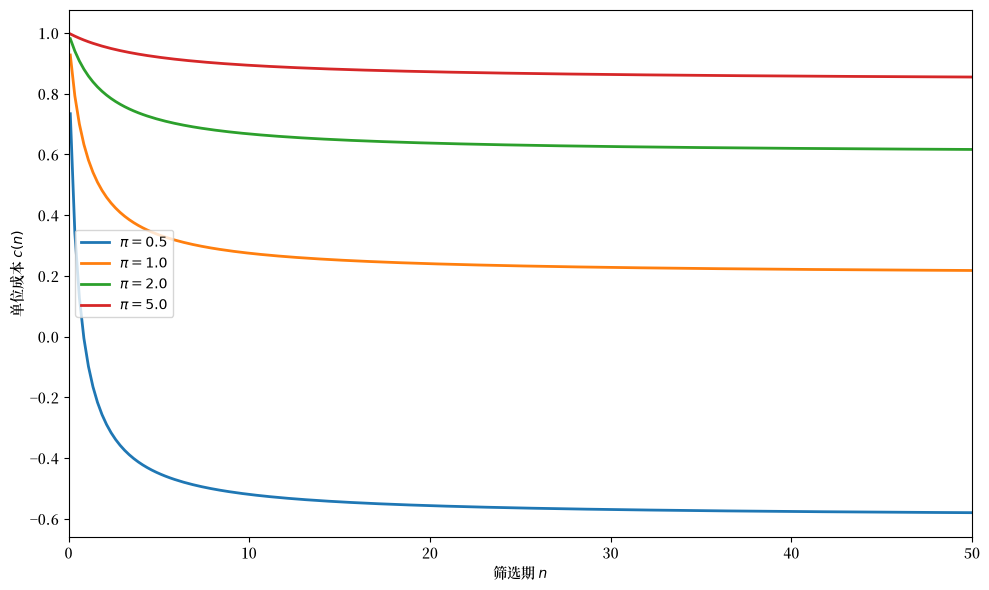

In [4]:
def cost_per_unit(n_vals, π, c_bar=1.0):
    """
    作为筛选期 n 函数的单位成本。
    """
    n_vals = np.asarray(n_vals, dtype=float)
    return c_bar - 0.7978 * n_vals / (π * (π + n_vals))


fig, ax = plt.subplots(figsize=(10, 6))

n_vals = np.linspace(0.1, 50, 200)

for π in [0.5, 1.0, 2.0, 5.0]:
    costs = cost_per_unit(n_vals, π)
    ax.plot(n_vals, costs, lw=2, label=fr'$\pi = {π}$')

ax.set_xlabel('筛选期 $n$')
ax.set_ylabel('单位成本 $c(n)$')
ax.legend()
ax.set_xlim(0, 50)
plt.tight_layout()
plt.show()

图表显示：

* 成本随着更多的筛选时间 $n$ 而下降
* 下降的速率是递减的（筛选的收益递减）
* 对于较小的先验精度 $\pi$（关于工人类型的初始不确定性更大），筛选带来的收益更大

这种收益递减的结构是*快速调整成本递增*的来源。


### 增长率与筛选时间

增长率越大，$n$ 就必须越小——即在分配到职务 2 或 3 之前花在筛选任务上的时间越少。

如果 $\gamma$ 是产出的增长率，$\rho$ 是离职率，$y_i$ 是当前第 $i$ 代员工的数量，那么

$$
(1 + \gamma) y_{i+1} = (1 - \rho) y_i
$$

令 $\xi = (1 - \rho)/(1 + \gamma)$，由上式得 $y_i = \xi^i y_0$。

对于固定系数技术，当前人员中代数大于 $n$ 的比例必须等于 $2\varphi / (\varphi_1 + 2\varphi)$，这给出：

$$
\xi^{n+1} = \frac{2\varphi}{\varphi_1 + 2\varphi}
$$ (eq:cutoff)

求解 $n$ 作为 $\gamma$ 的函数：

$$
n(\gamma) = \frac{\log(2\varphi) - \log(\varphi_1 + 2\varphi)}{\log(1 - \rho) - \log(1 + \gamma)} - 1 \quad \text{对于 } \gamma > -\rho
$$ (eq:n_gamma)

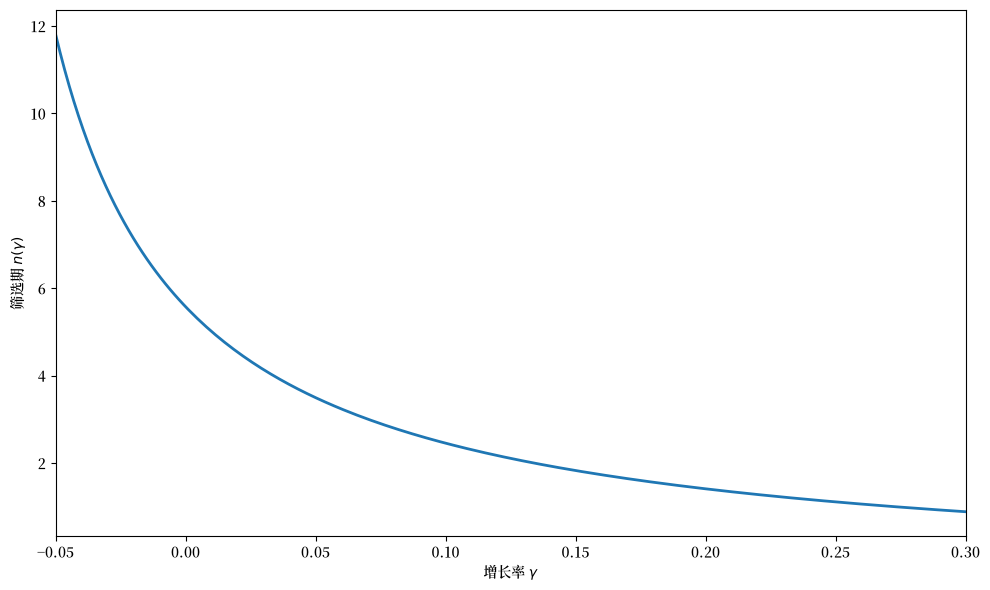

In [5]:
def screening_time(γ, ρ, φ1, φ):
    """
    作为增长率 γ 函数的筛选时间 n。
    """
    γ = np.asarray(γ, dtype=float)
    numerator = np.log(2 * φ) - np.log(φ1 + 2 * φ)
    denominator = np.log(1 - ρ) - np.log(1 + γ)
    return numerator / denominator - 1


ρ = 0.1
φ1 = 0.5
φ = 0.25

γ_vals = np.linspace(-0.05, 0.30, 200)

valid = γ_vals > -ρ
γ_valid = γ_vals[valid]
n_vals = screening_time(γ_valid, ρ, φ1, φ)
mask = n_vals > 0
γ_plot = γ_valid[mask]
n_plot = n_vals[mask]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(γ_plot, n_plot, lw=2)
ax.set_xlabel(r'增长率 $\gamma$')
ax.set_ylabel(r'筛选期 $n(\gamma)$')
ax.set_xlim(γ_plot[0], γ_plot[-1])
plt.tight_layout()
plt.show()

图表显示了关键的权衡：*更快的增长迫使筛选期更短*。

当增长迅速时，新工人必须更快地从筛选任务提升到生产性任务，因此在分配之前收集到的关于每个工人的信息更少。


### 综合效应：增长率与单位成本

将函数 $c(n)$ 和 $n(\gamma)$ 组合起来揭示了单位成本如何依赖于增长率：

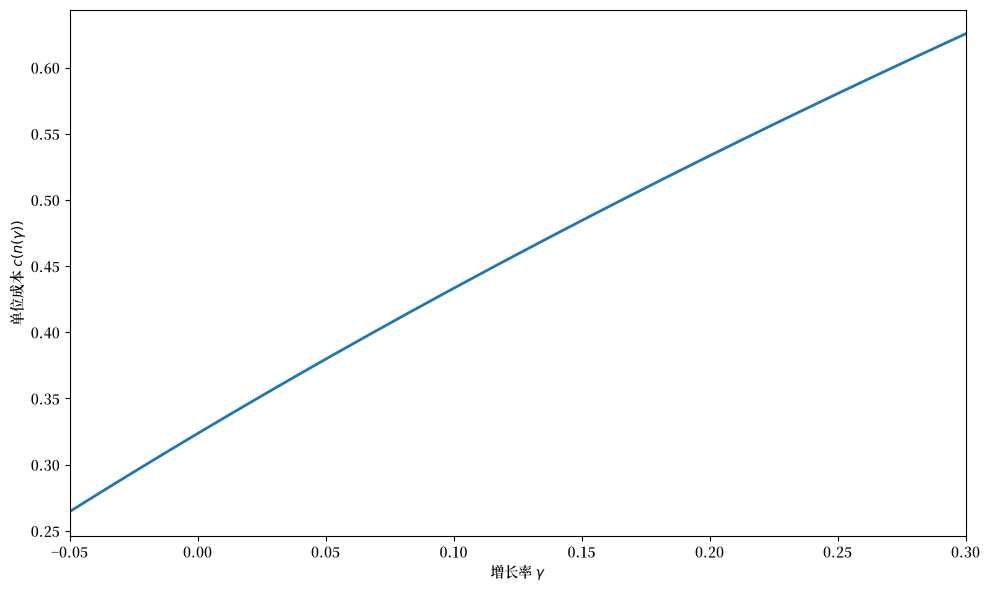

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

π = 1.0
c_bar = 1.0

n_of_γ = screening_time(γ_plot, ρ, φ1, φ)
costs_of_γ = cost_per_unit(n_of_γ, π, c_bar)

ax.plot(γ_plot, costs_of_γ, lw=2)
ax.set_xlabel(r'增长率 $\gamma$')
ax.set_ylabel(r'单位成本 $c(n(\gamma))$')
ax.set_xlim(γ_plot[0], γ_plot[-1])
plt.tight_layout()
plt.show()

这确立了关键结果：*快速调整的成本递增内生地产生*于筛选与增长之间的权衡。

企业增长越快，其筛选工人的时间就越少，工人与任务之间的匹配就越差，单位生产成本就越高。


## 行业均衡

```{index} single: Organization Capital; Industry Equilibrium
```

在这个模型中，企业增长率与企业规模无关，因为技术约束的数学结构与 {cite:t}`lucas1967adjustment` 中所考虑的相同，只是组织资本的存量是一个向量而不是一个标量。

面对价格接受型企业的技术集是一个**凸锥**：存在规模报酬不变。

规模报酬不变和内部调整成本，以及在企业之间转移资本的一些成本，产生了*与企业规模无关*的最优企业增长率——这就是基布拉特定律。

有界的、向下倾斜的反行业需求函数为

$$
P_t = p(Q_t, u_t)
$$

其中 $Q_t$ 是所有企业产出之和，$u_t$ 是受平稳马尔可夫过程约束的需求冲击。

普雷斯科特和维斯彻使用 {cite:t}`Lucas_Prescott_1971` 的框架证明了竞争均衡的存在。

要最大化的贴现消费者剩余为

$$
\sum_{t=0}^{\infty} \beta^t \left\{ \int_0^{Q_t} p(y, u_t) dy - Bw - Q_t \sum_i (A_{i2t} + A_{i3t}) c(i) / \sum_i (A_{i2t} + A_{i3t}) \right\}
$$ (eq:surplus)

其中 $A_{i2t}, A_{i3t}$ 和 $B$ 分别通过对行业中所有企业求和 $a_{i2t}$、$a_{i3t}$ 和 $b$ 得到。


### 关键性质：增长率与规模无关

如果两个企业在某一时点的组织资本向量 $\underline{k}$ 成比例，那么它们在所有未来时期都将成比例。

也就是说，*增长率与企业规模无关*。

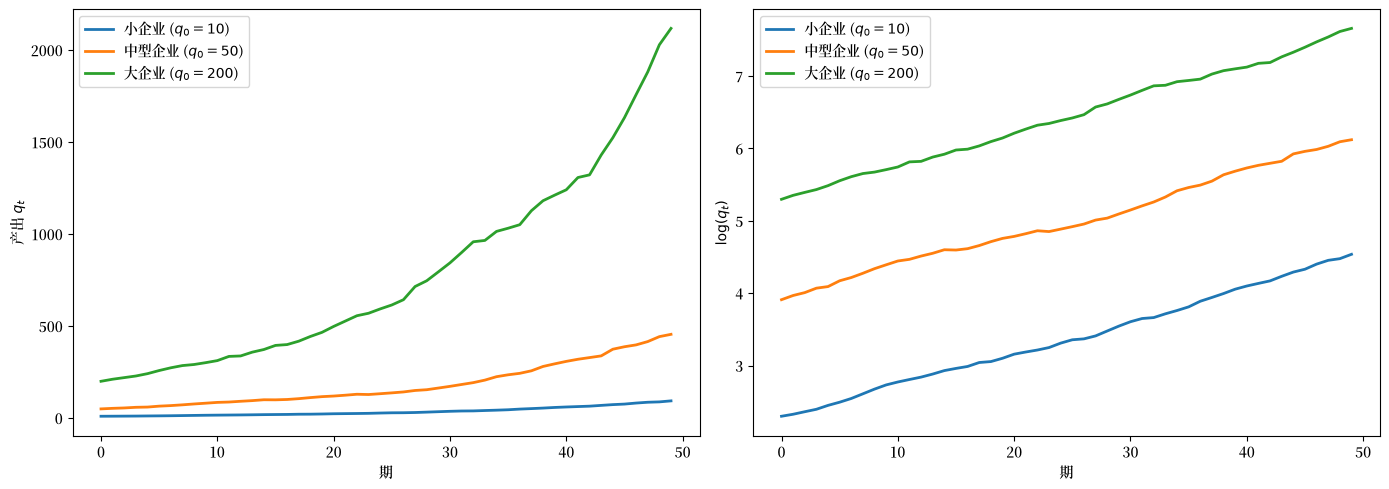

In [7]:
def simulate_firm_growth(T, γ, ρ, q0, seed=42):
    """
    模拟带有随机冲击的企业产出增长。
    """
    rng = np.random.default_rng(seed)
    output = np.zeros(T)
    output[0] = q0
    for t in range(1, T):
        shock = rng.normal(0, 0.02)
        output[t] = output[t-1] * (1 + γ + shock)
    return output


T = 50
γ_eq = 0.05
ρ = 0.1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for q0, label in [(10, '小企业'), (50, '中型企业'),
                   (200, '大企业')]:
    output = simulate_firm_growth(T, γ_eq, ρ, q0,
                                  seed=int(q0))
    ax.plot(range(T), output, lw=2, label=f'{label} ($q_0={q0}$)')
ax.set_xlabel('期')
ax.set_ylabel('产出 $q_t$')
ax.legend()

ax = axes[1]
for q0, label in [(10, '小企业'), (50, '中型企业'),
                   (200, '大企业')]:
    output = simulate_firm_growth(T, γ_eq, ρ, q0,
                                  seed=int(q0))
    ax.plot(range(T), np.log(output), lw=2,
            label=f'{label} ($q_0={q0}$)')
ax.set_xlabel('期')
ax.set_ylabel(r'$\log(q_t)$')
ax.legend()

plt.tight_layout()
plt.show()

右图显示所有企业以相同的速率增长，无论初始规模如何——对数产出路径是平行的。

这就是**基布拉特定律**：增长率与企业规模无关。

## 贝叶斯筛选模拟

```{index} single: Organization Capital; Bayesian Screening
```

让我们模拟单个企业的完整筛选和分配过程。

我们从总体中抽取工人，观察他们在筛选任务中的信号，然后根据后验均值将他们分配到适当的生产性任务。

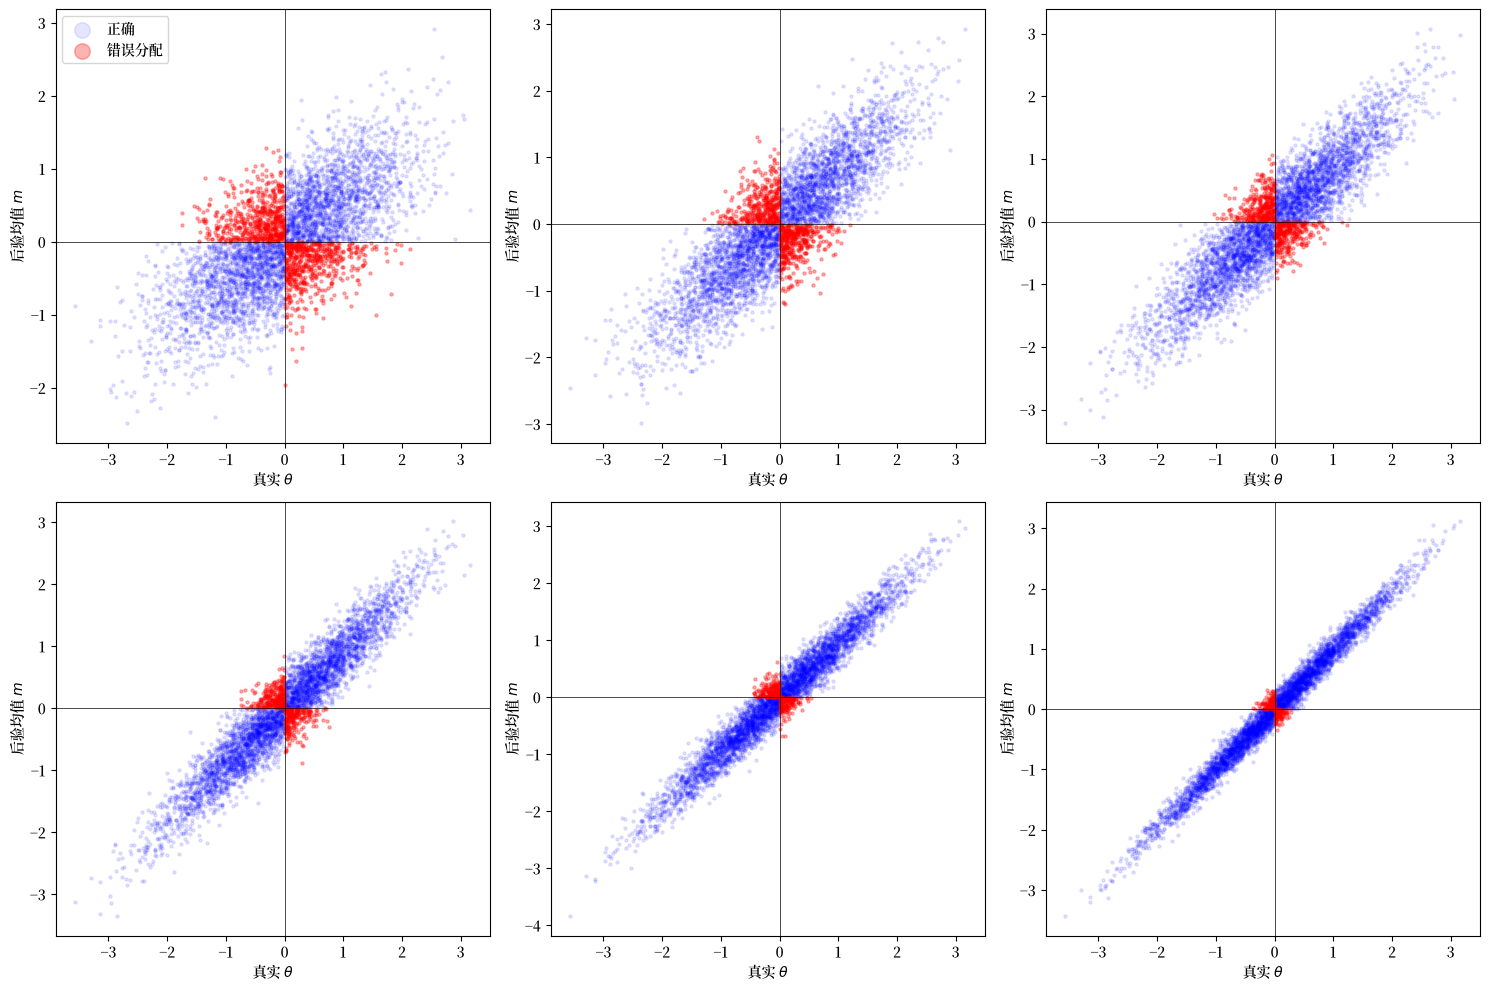

In [8]:
def simulate_screening(n_workers, n_screen, π, seed=123):
    """
    模拟工人的筛选和分配。
    """
    rng = np.random.default_rng(seed)

    θ = rng.normal(0, 1/np.sqrt(π), n_workers)
    signals = (θ[:, None]
               + rng.normal(0, 1, (n_workers, n_screen)))
    posterior_means = signals.sum(axis=1) / (π + n_screen)

    assignment = np.where(posterior_means > 0, 2, 3)
    correct_assignment = np.where(θ > 0, 2, 3)
    misassignment_rate = np.mean(assignment != correct_assignment)

    return {
        'theta': θ,
        'posterior_means': posterior_means,
        'assignment': assignment,
        'correct_assignment': correct_assignment,
        'misassignment_rate': misassignment_rate
    }


π = 1.0
n_workers = 5000
screening_periods = [1, 3, 5, 10, 20, 50]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

misassignment_rates = []

for idx, n_screen in enumerate(screening_periods):
    results = simulate_screening(n_workers, n_screen, π)
    misassignment_rates.append(results['misassignment_rate'])

    ax = axes[idx]
    θ = results['theta']
    m = results['posterior_means']

    correct = results['assignment'] == results['correct_assignment']
    ax.scatter(θ[correct], m[correct], alpha=0.1, s=5,
               color='blue', label='正确')
    ax.scatter(θ[~correct], m[~correct], alpha=0.3, s=5,
               color='red', label='错误分配')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    mis = results['misassignment_rate']
    ax.set_xlabel(r'真实 $\theta$')
    ax.set_ylabel('后验均值 $m$')
    if idx == 0:
        ax.legend(markerscale=5, loc='upper left')

plt.tight_layout()
plt.show()

红点是被*错误分配*的工人——由于后验均值相对于其真实 $\theta$ 具有错误的符号而被安排到错误的生产性任务中。

随着 $n$ 增加：
* 后验均值 $m$ 与 $\theta$ 的相关性更强
* 错误分配率下降

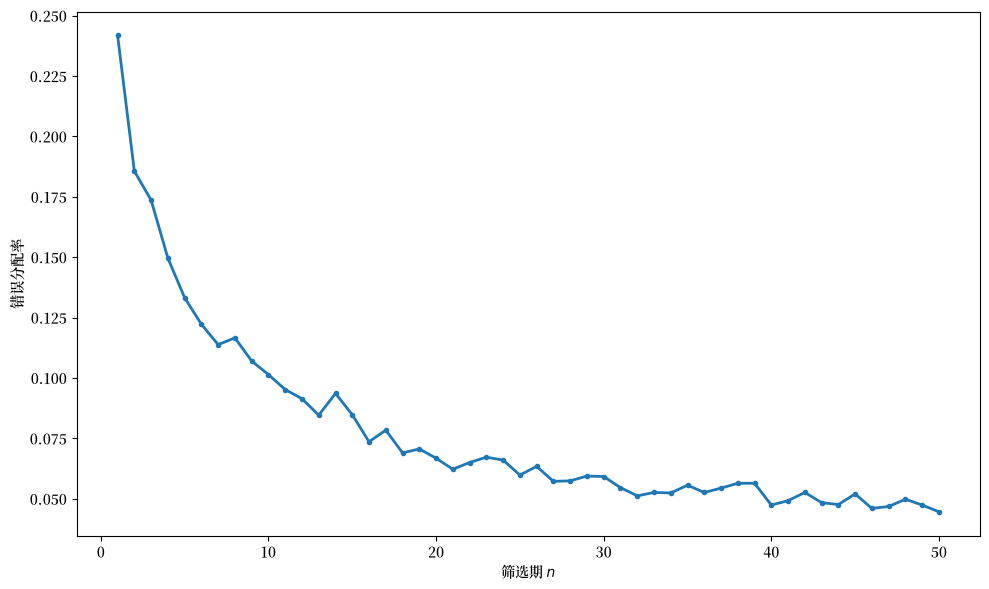

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

n_range = np.arange(1, 51)
mis_rates = []
for n_screen in n_range:
    results = simulate_screening(n_workers, n_screen, π)
    mis_rates.append(results['misassignment_rate'])

ax.plot(n_range, mis_rates, '-o', markersize=3, lw=2)
ax.set_xlabel('筛选期 $n$')
ax.set_ylabel('错误分配率')
plt.tight_layout()
plt.show()

这证实了理论预测：更好分配所带来的成本节约在筛选时间 $n$ 上呈现*收益递减*。

## 团队信息

```{index} single: Organization Capital; Team Information
```

人员信息不仅仅因为便于工人与任务的匹配而有价值。

人员信息的另一个同样有价值的用途是*工人与工人的匹配*。

对于企业内许多活动的表现来说，重要的不仅仅是分配到某项任务的个人的适应能力，还有该个人的特征与执行相关职责的其他人的特征的协调程度。

### 结构

假设工人被分组为团队，被分配到筛选任务的团队 $i$ 具有观察到的生产率指标

$$
z_{it} = \theta_i + \epsilon_{it}
$$

其中：
* $\theta_i$ 是与团队工人配对得如何直接相关的确定性成分
* $\epsilon_{it} \sim N(0, 1)$ 是独立同分布的随机成分

所有可能团队的 $\theta$ 近似地独立且正态分布 $N(\mu, 1/\pi)$。

在对团队 $i$ 进行 $n$ 次观察后，$\theta_i$ 的后验分布是正态分布，具有

$$
m = \mu + \frac{1}{\pi + n} \sum_{k=1}^{n} (z_k - \mu)
$$

以及精度 $h = \pi + n$。

如果团队的解散也会解散所积累的信息，那么团队信息模型与人员信息模型具有*相同的数学结构*。

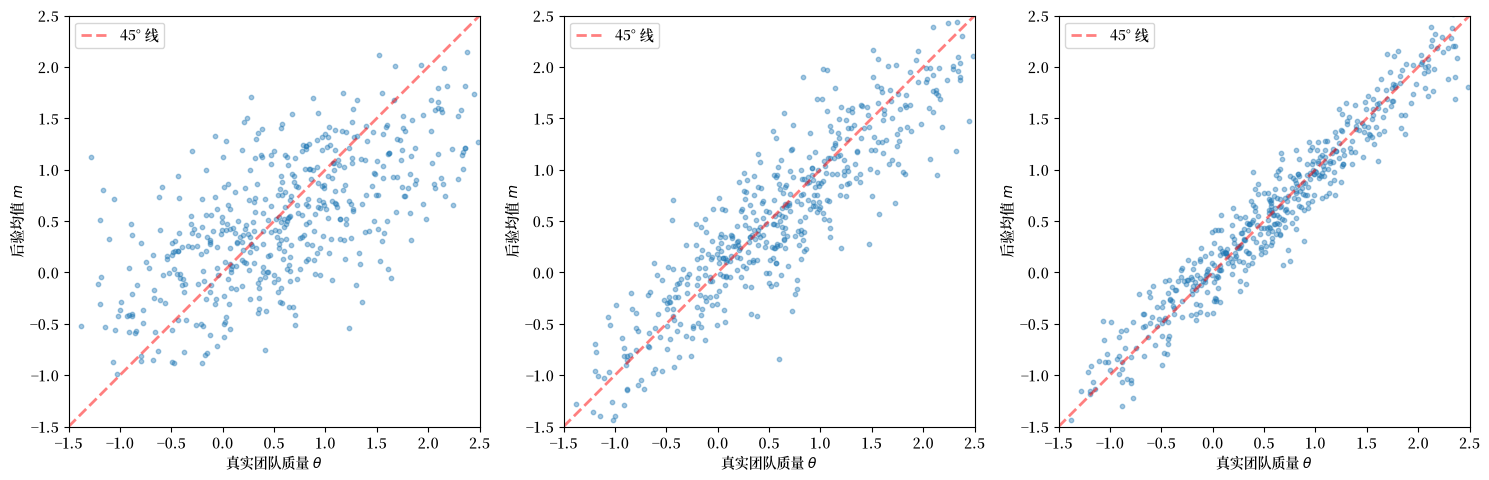

In [10]:
def simulate_team_screening(n_teams, n_screen, π, μ=0.5,
                            seed=456):
    """
    使用贝叶斯更新模拟团队筛选。
    """
    rng = np.random.default_rng(seed)

    θ = rng.normal(μ, 1/np.sqrt(π), n_teams)
    signals = (θ[:, None]
               + rng.normal(0, 1, (n_teams, n_screen)))
    z_bar = signals.mean(axis=1)
    post_means = μ + n_screen * (z_bar - μ) / (π + n_screen)
    post_prec = π + n_screen

    return {
        'theta': θ,
        'posterior_means': post_means,
        'posterior_precision': post_prec
    }


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, n_screen in enumerate([1, 5, 20]):
    results = simulate_team_screening(500, n_screen, π=1.0, μ=0.5)

    ax = axes[idx]
    ax.scatter(results['theta'], results['posterior_means'],
               alpha=0.4, s=10)
    lims = [-1.5, 2.5]
    ax.plot(lims, lims, 'r--', alpha=0.5, lw=2, label='45° 线')
    ax.set_xlabel(r'真实团队质量 $\theta$')
    ax.set_ylabel('后验均值 $m$')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend()
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

与个人筛选一样，更多的观察改善了团队质量估计的精度。

快速增长迫使在团队分配必须最终确定之前进行更少的观察，从而导致更高的成本。


## 企业专用人力资本

```{index} single: Organization Capital; Human Capital
```

第三个例子：组织资本由企业员工的**人力资本**构成。

组织作为生产单位有效运作的能力在很大程度上取决于员工技能的水平和协调程度。

```{note}
员工的人力资本作为企业资本存量一部分的论点已经确立（参见 {cite:t}`Becker_1975`）。

未来的生产率取决于未来的人力资本水平，但为了获得未来的人力资本，需要在当下牺牲实际资源。
```

关键特征是：

* 产出和技能提升是由拥有不同技能水平的劳动投入组合而产生的**联合产品**

* 有经验和无经验的工人在几种可用技术过程之一中组合起来生成企业的产品，在此过程中，劳动力的整体能力得到提升

* 当前产出和未来人力资本之间的转换前沿是*凹的*且线性齐次的

这使技术集具有以原点为顶点的闭凸锥的结构——足以使企业实现最优的比例增长。

### 凹转换前沿

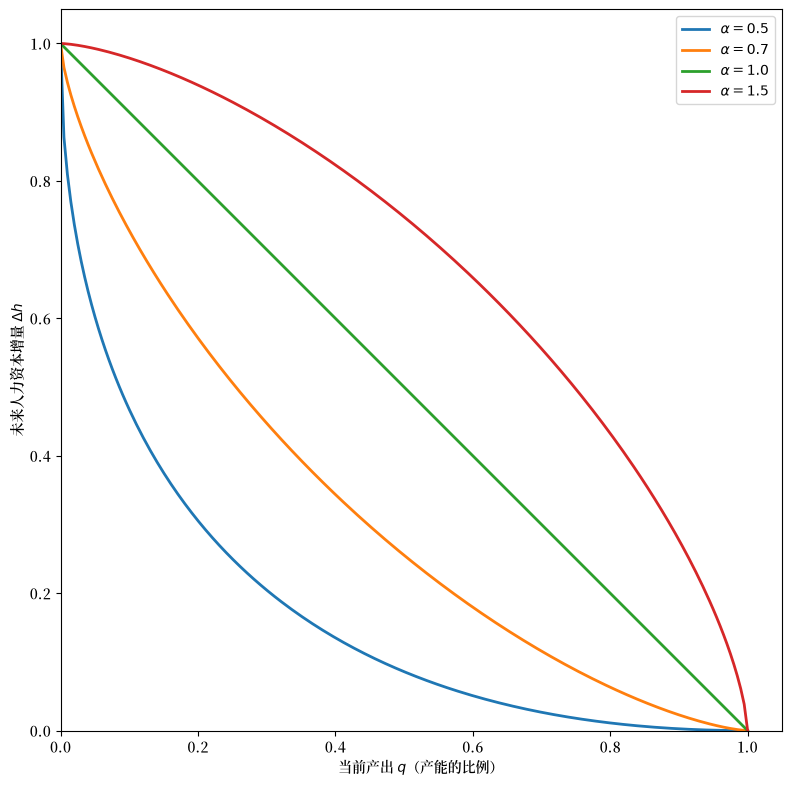

In [11]:
def transformation_frontier(q, α=0.7):
    """
    产出与人力资本之间的凹转换前沿。
    """
    q = np.asarray(q, dtype=float)
    return (1 - q**α)**(1/α)


fig, ax = plt.subplots(figsize=(8, 8))

q_vals = np.linspace(0, 1, 200)

for α in [0.5, 0.7, 1.0, 1.5]:
    hk = transformation_frontier(q_vals, α)
    ax.plot(q_vals, hk,
            label=fr'$\alpha = {α}$', lw=2)

ax.set_xlabel('当前产出 $q$（产能的比例）')
ax.set_ylabel('未来人力资本增量 $\\Delta h$')
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

转换前沿的凹性意味着从极度不平衡的生产和学习活动组合转向更平衡的组合几乎不需要什么牺牲。

但是主要由学习组成的工作日也有收益递减，这产生了快速调整的成本。


## 转移组织资本的成本

```{index} single: Organization Capital; Transfer Costs
```

如果将组织资本从一个企业转移到另一个企业没有成本，那么该模型就不会对企业的增长率施加约束。

那样，企业可以合并、剥离或挖走彼此的员工而不受成本惩罚，从而产生不受模型限制的增长模式。

然而，组织资本*不能*无成本地移动：

1. *搬迁具有破坏性*：从一个地方搬到另一个地方对员工和家庭都具有破坏性

2. *信息是企业专用的*：使某人在一个组织中富有生产力的信息集可能不会使该人在另一个组织中同样富有生产力，即使两个企业生产相同的产出

   * 在一家企业熟练使用计算机系统
   * 知道出现问题时该向谁求助
   * 与买家或卖家的融洽关系

这些都是一个企业中*无法无成本转移*到另一个企业的组织资本类型。


## 总结与启示

普雷斯科特-维斯彻模型提供了一个统一的框架，其中：

* 企业作为一个实体存在，因为它是积累、存储和使用信息的有效结构

* *规模报酬不变*的产生是因为一旦发现工人类型的最佳组合，就没有什么能阻止企业复制这些组合并按比例获得产品收益

* *调整成本递增*内生地产生于当前生产与组织资本投资之间的权衡

* *基布拉特定律*——增长率与企业规模无关——是一个自然的推论

* 大企业的增长率应显示出比小企业*更小的方差*，因为大企业本质上是较小生产单位的组合

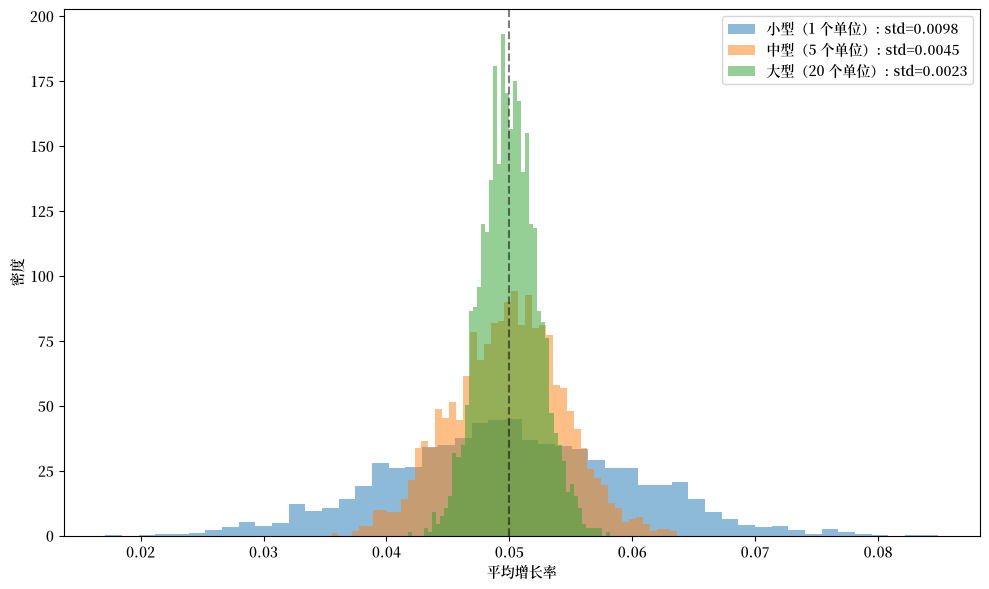

In [12]:
def simulate_growth_rate_distribution(n_firms, n_subunits, γ,
                                      σ, T=100, seed=789):
    """
    模拟不同规模企业的增长率分布。
    """
    rng = np.random.default_rng(seed)
    subunit_growth = rng.normal(γ, σ,
                                (n_firms, n_subunits, T))
    firm_growth = subunit_growth.mean(axis=1)
    return firm_growth.mean(axis=1)


fig, ax = plt.subplots(figsize=(10, 6))

sizes = {'小型（1 个单位）': 1,
         '中型（5 个单位）': 5,
         '大型（20 个单位）': 20}

γ = 0.05
σ = 0.10

for label, n_sub in sizes.items():
    rates = simulate_growth_rate_distribution(
        2000, n_sub, γ, σ)
    ax.hist(rates, bins=50, alpha=0.5, density=True,
            label=f'{label}: std={rates.std():.4f}')

ax.set_xlabel('平均增长率')
ax.set_ylabel('密度')
ax.legend()
ax.axvline(γ, color='k', linestyle='--',
           label=r'$\gamma$', alpha=0.5)
plt.tight_layout()
plt.show()

图表显示，尽管所有企业都有*相同的平均增长率*（基布拉特定律），大企业在实现的增长率中显示出*更小的方差*，因为它们实际上是独立子单位的组合。

这与 {cite:t}`Mansfield_1962` 和 {cite:t}`Hymer_Pashigian_1962` 的经验发现一致。

普雷斯科特-维斯彻理论的本质是企业的性质与*组织资本*相关联。

将企业与其他关系区分开来的是，它是一种结构，在这种结构中，代理人有激励以一种比可能的替代制度成本更低的方式来获取和揭示信息。